# AAV Variant Selection Protocol — Full Simulation

Full pipeline from initial plasmid pool to post-selectivity reads, in two parts:

**production/variability:**
$$X_0 \xrightarrow{\text{NGS}} \lambda_0 \xrightarrow{\text{sampling}} X_1 \xrightarrow{\text{HEK transfection + capsids}} P(s) \xrightarrow{\text{NGS}} \lambda_1'$$

**selectivity:**
$$\lambda_1' \xrightarrow{\tilde{s}_j = s_j + \varepsilon\mathcal{N}(0,1)} \xrightarrow{\text{softmax enrichment}} \xrightarrow{\text{sequencing}} n_2$$

Data structures: JAX arrays throughout. Sequences: `(num_sequences, L)` int. Counts: `(num_sequences,)` float.

# PART 1 : LINEAR MODEL

### Here we consider each amino-acid independant from the other

## 1. Imports

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

## 2. Sequence generation and score model

Each variant is a sequence of `L` amino acids (0-indexed, 0–19).  
The score is a linear model over a weight matrix $w \in \mathbb{R}^{20 \times L}$:
$$s(a_1, \dots, a_L) = \sum_{i=1}^{L} w_{a_i, i}$$

Two **independent** score functions capture distinct biological properties:

| Score | Matrix | Role |
|---|---|---|
| Viability $s^{\mathrm{viab}}$ | `viability_weights` | capacity to form functional capsids |
| Selectivity $s^{\mathrm{sel}}$ | `selectivity_weights` | capacity to transduce the target tissue |

Both matrices are random for now; they will eventually reflect measured biological data.


In [ ]:
key = jax.random.key(42)
key_seq, key_viab_w, key_sel_w, key_n0, key_run = jax.random.split(key, 5)

num_sequences   = 10000
num_positions   = 7     # L
num_amino_acids = 20

# Random library: sequences and initial read counts
sequences = jax.random.randint(
    key_seq, shape=(num_sequences, num_positions),
    minval=0, maxval=num_amino_acids
)

# Two independent score matrices
viability_weights   = jax.random.normal(key_viab_w, shape=(num_amino_acids, num_positions))
selectivity_weights = jax.random.normal(key_sel_w,  shape=(num_amino_acids, num_positions))

n0 = jax.random.randint(
    key_n0, shape=(num_sequences,), minval=10, maxval=1000
).astype(jnp.float32)

print(f"Library: {num_sequences} sequences of length {num_positions}")
print(f"First sequences:\n{sequences[:3]}")


Library: 10000 sequences of length 7
First sequences:
[[ 4 11 19  1 10 19  0]
 [ 9  8 11 16  1  2  7]
 [11  4 19  7  3 19 13]]


In [ ]:
def calculate_scores(seqs, w):
    """
    Compute the selectivity score for each sequence (vectorised).

    Parameters
    ----------
    seqs : (num_sequences, L) int array  — amino acid indices (0-indexed)
    w    : (num_amino_acids, L) float array — per-position per-AA weights

    Returns
    -------
    (num_sequences,) float array
    """
    return jnp.sum(w[seqs, jnp.arange(seqs.shape[1])], axis=1)

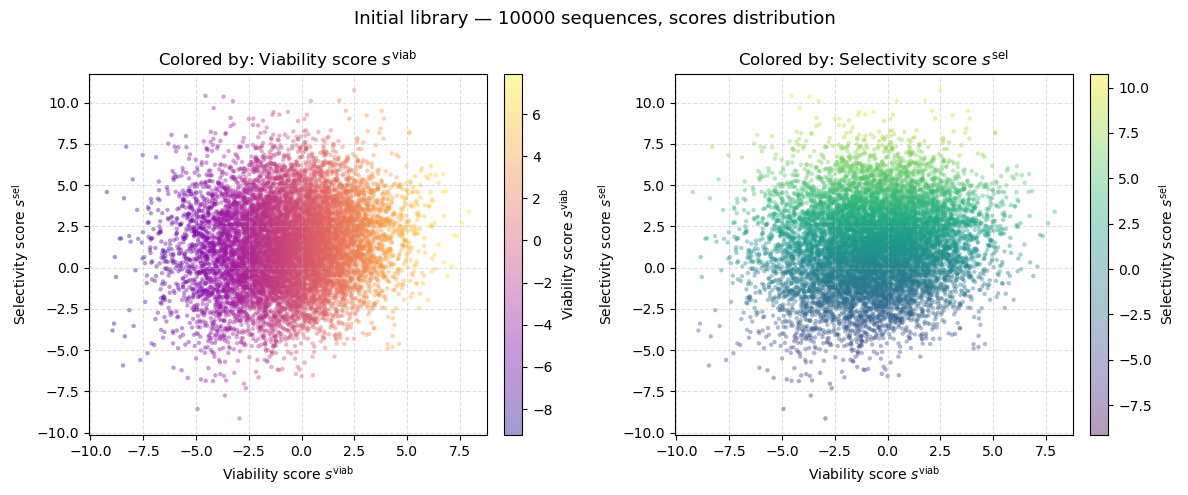

In [ ]:
# Compute scores from initial library
viability_scores   = calculate_scores(sequences, viability_weights)
selectivity_scores = calculate_scores(sequences, selectivity_weights)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, color_scores, cmap, label in [
    (axes[0], viability_scores,   'plasma',  r'Viability score $s^{\mathrm{viab}}$'),
    (axes[1], selectivity_scores, 'viridis', r'Selectivity score $s^{\mathrm{sel}}$'),
]:
    sc = ax.scatter(viability_scores, selectivity_scores,
                    c=color_scores, cmap=cmap, alpha=0.4, edgecolors='none', s=10)
    plt.colorbar(sc, ax=ax, label=label, fraction=0.046, pad=0.04)
    ax.set_xlabel(r'Viability score $s^{\mathrm{viab}}$')
    ax.set_ylabel(r'Selectivity score $s^{\mathrm{sel}}$')
    ax.set_title(f'Colored by: {label}')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle(f'Initial library — {num_sequences} sequences, scores distribution', fontsize=13)
plt.tight_layout()
plt.show()


## 3. NGS pipeline

The full NGS process consists of three sequential steps:
1. **Sampling** — a subset of $N_1$ molecules is drawn from the pool (Poisson approximation to multinomial)
2. **PCR amplification** — $M$ cycles with Michaelis–Menten kinetics
3. **Sequencing** — $D$ reads sampled from the amplified pool (Poisson approximation)

The PCR dynamics per cycle $n$ are:
$$X_s^{(n+1)} = X_s^{(n)} + \mathrm{Poisson}\!\left(X_s^{(n)} \cdot p_n\right), \qquad p_n = \left(1 + \frac{\sum_{s'} X_{s'}^{(n)}}{K_{MM}}\right)^{-1}$$
(Poisson approximation to Binomial — valid when $p_n$ is small.)

In [ ]:
class Sequence():
    def __init__(self, X, D, key) -> None:
        """
        X   : (num_sequences,) float array — pool counts
        D   : int — sequencing depth
        key : JAX random key
        """
        self.X   = X
        self.D   = D
        self.key = key
 
    def _next_key(self) -> jax.Array:
        self.key, subkey = jax.random.split(self.key)
        return subkey
 
    def sample_sequences(self) -> jax.Array:
        proportions = self.X / jnp.sum(self.X)
        return jax.random.poisson(self._next_key(), proportions * self.D)
 
    def sequence_reads(self) -> jax.Array:
        proportions = self.X / jnp.sum(self.X)
        return jax.random.poisson(self._next_key(), proportions * self.D)
 
 
class Sequence_NGS_pipeline(Sequence):
    def __init__(self, X, D, key, M, K_MM, N_pcr) -> None:
        super().__init__(X, D, key)
        self.M     = M
        self.K_MM  = K_MM
        self.N_pcr = N_pcr
 
    def pcr_amplification(self) -> jax.Array:
        """
        M cycles of PCR amplification with Michaelis-Menten kinetics.
 
        At each cycle n:
            p_n = 1 / (1 + sum(X) / K_MM)
            X  <- X + Poisson(X * p_n)
 
        Returns
        -------
        (num_sequences,) float array — amplified pool
        """
        self.X = self.X.astype(jnp.float32)
        for _ in range(self.M):
            p_n    = 1.0 / (1.0 + jnp.sum(self.X) / self.K_MM)
            self.X = self.X + jax.random.poisson(self._next_key(), self.X * p_n).astype(jnp.float32)
        return self.X
 
    def ngs(self) -> jax.Array:
        """
        Full NGS process: sampling -> PCR amplification -> sequencing.
 
        Returns
        -------
        (num_sequences,) int array — read counts
        """
        X_original = self.X
        self.X = self.sample_sequences().astype(jnp.float32)
        self.X = self.pcr_amplification()
        result = self.sequence_reads()
        self.X = X_original
        return result

In [ ]:
def sample_sequences(X, D, key):
    """Poisson approximation to multinomial sampling: ~ Poisson(N1 * X[s] / sum(X))."""
    proportions = X / jnp.sum(X)
    return jax.random.poisson(key, proportions * D)


def ngs_simple(X, D, N_pcr, key):
    """
    Simple Poisson NGS (Sequence base class): sampling -> sequencing, no PCR.
    """
    seq       = Sequence(X, N_pcr, key)
    X_sampled = seq.sample_sequences().astype(jnp.float32)
    reader    = Sequence(X_sampled, D, seq.key)
    return reader.sequence_reads()


def ngs_full(X, D, N_pcr, key, M, K_MM):
    """
    Full NGS pipeline (Sequence_NGS_pipeline): sampling -> PCR amplification -> sequencing.
    """
    pipeline = Sequence_NGS_pipeline(X, D, key, M, K_MM, N_pcr)
    return pipeline.ngs()


## 4. Transfection and capsid production

Production depends on the **viability score** $s^{\mathrm{viab}}(s)$:  
a sequence with a higher viability score produces more capsids per transfected cell.

- HEK cells transfected: $T(s) \sim \mathrm{Poisson}(\rho\, x_1(s))$
- Capsids per transfected cell: modulated by $\exp(s^{\mathrm{viab}}(s) / T_{\mathrm{viab}})$
- Total capsids by compound Poisson:
$$P(s) \sim \mathrm{Poisson}\!\left(\rho \cdot x_1(s) \cdot \alpha \cdot \exp\!\left(\frac{s^{\mathrm{viab}}(s)}{T_{\mathrm{viab}}}\right)\right)$$

When $T_{\mathrm{viab}} \to \infty$, reduces to the score-independent case.  
Experimental estimates: $\rho \approx 1.2 \times 10^{-4}$, $\alpha \approx 4000$.


In [ ]:
def produce_capsids(x1, viability_scores, alpha, rho, T_viab, key):
    """
    HEK transfection and capsid production modulated by viability score.

    P(s) ~ Poisson(rho * x1[s] * alpha * exp(s_viab[s] / T_viab))

    Parameters
    ----------
    x1               : (num_sequences,) float array — plasmid counts
    viability_scores : (num_sequences,) float array — viability scores s_viab
    alpha            : float — baseline capsid yield per transfected cell (~4000)
    rho              : float — mean HEK cells transfected per plasmid (~1.2e-4)
    T_viab           : float — viability temperature (larger = more uniform)
    key              : JAX random key

    Returns
    -------
    (num_sequences,) int array — capsid counts P(s)
    """
    mu = rho * x1.astype(jnp.float32) * alpha * jnp.exp(viability_scores / T_viab)
    return jax.random.poisson(key, mu)


## 5. Full protocol

### Production phase
1. **NGS** on $X_0$ $\rightarrow$ $\lambda_0(s)$
2. **Sampling** $X_0 \rightarrow X_1$
3. **HEK transfection + capsid production** modulated by $s^{\mathrm{viab}}$ $\rightarrow$ $P(s)$
4. **NGS** on capsid pool $\rightarrow$ $\lambda_1'(s)$

### Selectivity phase
5. **Noisy selectivity score**: $\tilde{s}^{\mathrm{sel}}_j = s^{\mathrm{sel}}_j + \varepsilon \mathcal{N}(0,1)$
6. **Softmax enrichment**: weight $\lambda_1'(s)$ by $\exp(\tilde{s}^{\mathrm{sel}}_j / T_{\mathrm{sel}})$
7. **Final sequencing** $\rightarrow$ $n_2$


In [1]:
rho   = 1.2e-4
alpha = 4000

epsilon = 0.3
T_sel   = 0.5    # selectivity temperature
T_viab  = 1.0    # viability temperature (larger = more uniform production)
M       = 5
K_MM    = 1000.0
N_pcr   = 100_000
D       = 50_000
N1      = D

In [ ]:
def protocol(n0, sequences, viability_weights, selectivity_weights,
             epsilon_viability = epsilon, epsilon_selectivity = epsilon, 
             alpha = alpha, rho = rho, T_sel = T_sel, T_viab = T_viab, M = M, 
             K_MM = K_MM, D = D, N_pcr = N_pcr, N1 = N1, key = key,
             use_full_ngs=True):
    """
    Full AAV selection protocol simulation.

    Parameters
    ----------
    viability_weights   : (num_amino_acids, L) — weight matrix for viability score
    selectivity_weights : (num_amino_acids, L) — weight matrix for selectivity score
    T_sel               : float — selectivity temperature (softmax enrichment)
    T_viab              : float — viability temperature (capsid production)
    use_full_ngs        : bool  — True: PCR pipeline, False: simple Poisson

    Returns
    -------
    lambda0, capsids, lambda1p, n2
    """
    key, k_ngs0, k_sample, k_noise1, k_capsids, k_ngs1, k_noise2, k_ngs2 = jax.random.split(key, 8)

    viability_scores   = calculate_scores(sequences, viability_weights)
    selectivity_scores = calculate_scores(sequences, selectivity_weights)

    if use_full_ngs:
        _ngs = lambda X, k: ngs_full(X, D, N_pcr, k, M, K_MM)
    else:
        _ngs = lambda X, k: ngs_simple(X, D, N_pcr, k)

    ### ------------- Production Phase ------------- ###
    lambda0  = _ngs(n0, k_ngs0).astype(jnp.float32)
    x1       = sample_sequences(lambda0, N1, k_sample).astype(jnp.float32)
    v_tilde = viability_scores + epsilon_viability * jax.random.normal(k_noise1, shape=viability_scores.shape)
    capsids  = produce_capsids(x1, v_tilde, alpha, rho, T_viab, k_capsids).astype(jnp.float32)
    lambda1p = _ngs(capsids, k_ngs1).astype(jnp.float32)

    ### ------------- Selectivity Phase ------------- ###
    s_tilde     = selectivity_scores + epsilon_selectivity * jax.random.normal(k_noise2, shape=selectivity_scores.shape)
    post_select = lambda1p * jnp.exp(s_tilde / T_sel)
    n2_prime    = post_select / jnp.sum(post_select) * D
    n2          = jax.random.poisson(k_ngs2, n2_prime).astype(jnp.float32)

    return lambda0, capsids, lambda1p, n2


## 6. Run

In [ ]:
viability_scores   = calculate_scores(sequences, viability_weights)
selectivity_scores = calculate_scores(sequences, selectivity_weights)

key_simple, key_full = jax.random.split(key_run)

# Simulation 1: simple Poisson NGS (no PCR)
lambda0_s, capsids_s, lambda1p_s, n2_s = protocol(
    n0, sequences, viability_weights, selectivity_weights,
    epsilon, epsilon, alpha, rho, T_sel, T_viab, M, K_MM, D, N_pcr, N1,
    key_simple, use_full_ngs=False
)

# Simulation 2: full NGS pipeline (PCR)
lambda0_f, capsids_f, lambda1p_f, n2_f = protocol(
    n0, sequences, viability_weights, selectivity_weights,
    epsilon, epsilon, alpha, rho, T_sel, T_viab, M, K_MM, D, N_pcr, N1,
    key_full, use_full_ngs=True
)

for label, l0, caps, lp, n2 in [
    ("Simple Poisson", lambda0_s, capsids_s, lambda1p_s, n2_s),
    ("Full NGS",       lambda0_f, capsids_f, lambda1p_f, n2_f),
]:
    print(f"{label}:")
    print(f"  lambda0  total={int(jnp.sum(l0)):>10,}  non-zero={int(jnp.sum(l0>0))}")
    print(f"  capsids  total={int(jnp.sum(caps)):>10,}  non-zero={int(jnp.sum(caps>0))}")
    print(f"  lambda1p total={int(jnp.sum(lp)):>10,}  non-zero={int(jnp.sum(lp>0))}")
    print(f"  n2       total={int(jnp.sum(n2)):>10,}  non-zero={int(jnp.sum(n2>0))}")


Simple Poisson:
  lambda0  total=    49,676  non-zero=8831
  capsids  total=   221,400  non-zero=4986
  lambda1p total=    49,892  non-zero=2937
  n2       total=    50,273  non-zero=183
Full NGS:
  lambda0  total=    50,092  non-zero=8445
  capsids  total=   215,431  non-zero=4827
  lambda1p total=    49,963  non-zero=2638
  n2       total=    50,094  non-zero=214


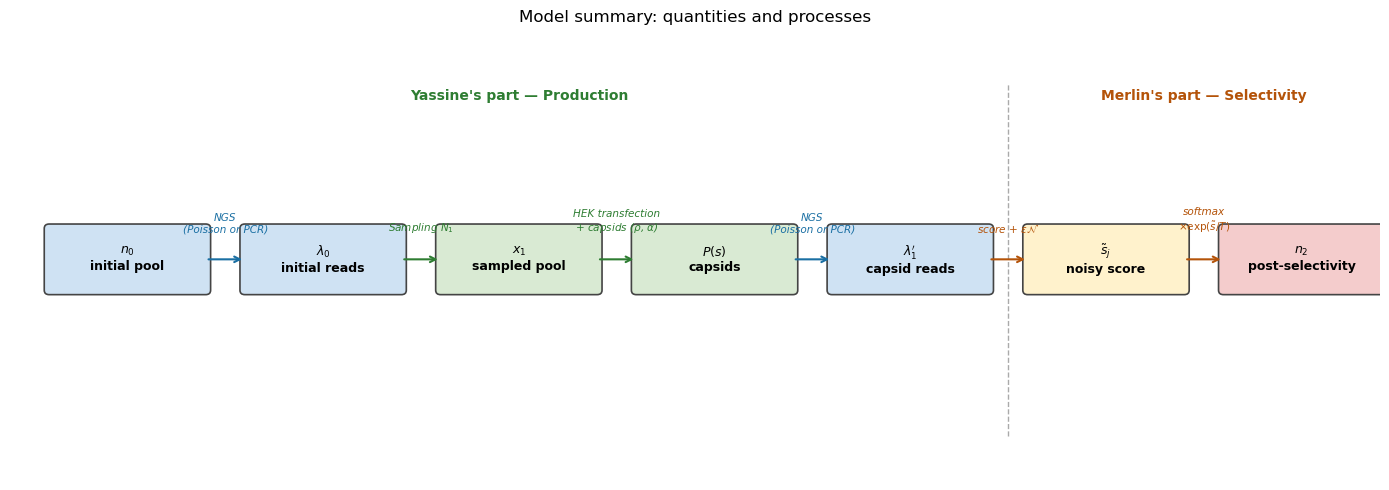

In [ ]:
import matplotlib.patches as mpatches

# Schema: quantities and flow of the model
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')

# ── helpers ─────────────────────────────────────────────────────────────────
BOX_W, BOX_H = 1.6, 0.7

def box(cx, cy, label, color):
    ax.add_patch(mpatches.FancyBboxPatch(
        (cx - BOX_W/2, cy - BOX_H/2), BOX_W, BOX_H,
        boxstyle='round,pad=0.05', fc=color, ec='#444', lw=1.2, zorder=3
    ))
    ax.text(cx, cy, label, ha='center', va='center', fontsize=9,
            fontweight='bold', zorder=4)

def arrow(x0, x1, y, label, color='#555'):
    ax.annotate('', xy=(x1 - BOX_W/2, y), xytext=(x0 + BOX_W/2, y),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    ax.text((x0 + x1)/2, y + 0.28, label, ha='center', va='bottom',
            fontsize=7.5, color=color, style='italic')

# ── quantities (boxes) ──────────────────────────────────────────────────────
#   x positions:  1.2   3.2   5.2   7.2   9.2  11.2  13.2
Y = 2.5
QTY = [
    (1.2,  r'$n_0$'         + '\ninitial pool',         '#cfe2f3'),
    (3.2,  r'$\lambda_0$'   + '\ninitial reads',        '#cfe2f3'),
    (5.2,  r'$x_1$'         + '\nsampled pool',         '#d9ead3'),
    (7.2,  r'$P(s)$'        + '\ncapsids',              '#d9ead3'),
    (9.2,  r"$\lambda_1'$"  + '\ncapsid reads',         '#cfe2f3'),
    (11.2, r'$\tilde{s}_j$' + '\nnoisy score',          '#fff2cc'),
    (13.2, r'$n_2$'         + '\npost-selectivity',     '#f4cccc'),
]
for cx, label, color in QTY:
    box(cx, Y, label, color)

# ── arrows (processes) ──────────────────────────────────────────────────────
PROC = [
    (1.2,  3.2,  'NGS\n(Poisson or PCR)',          '#1a6fa3'),
    (3.2,  5.2,  'Sampling $N_1$',                '#2e7d32'),
    (5.2,  7.2,  'HEK transfection\n+ capsids ($\\rho$, $\\alpha$)', '#2e7d32'),
    (7.2,  9.2,  'NGS\n(Poisson or PCR)',          '#1a6fa3'),
    (9.2,  11.2, 'score + $\\varepsilon\\mathcal{N}$', '#b45309'),
    (11.2, 13.2, 'softmax\n$\\times\\exp(\\tilde{s}/T)$', '#b45309'),
]
for x0, x1, label, color in PROC:
    arrow(x0, x1, Y, label, color)

# ── section labels ──────────────────────────────────────────────────────────
ax.text(5.2, 4.3, "Yassine's part — Production",
        ha='center', fontsize=10, color='#2e7d32', fontweight='bold')
ax.text(12.2, 4.3, "Merlin's part — Selectivity",
        ha='center', fontsize=10, color='#b45309', fontweight='bold')
ax.axvline(10.2, color='#aaa', lw=1, ls='--', ymin=0.1, ymax=0.9)

plt.title('Model summary: quantities and processes', fontsize=12, pad=12)
plt.tight_layout()
plt.show()


## 7a. Simple Poisson NGS

No PCR amplification — sampling + sequencing only (`Sequence` base class).

/var/folders/xf/g2dzx3814xx2yfk3fln8r_zc0000gn/T/ipykernel_28141/3629221837.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


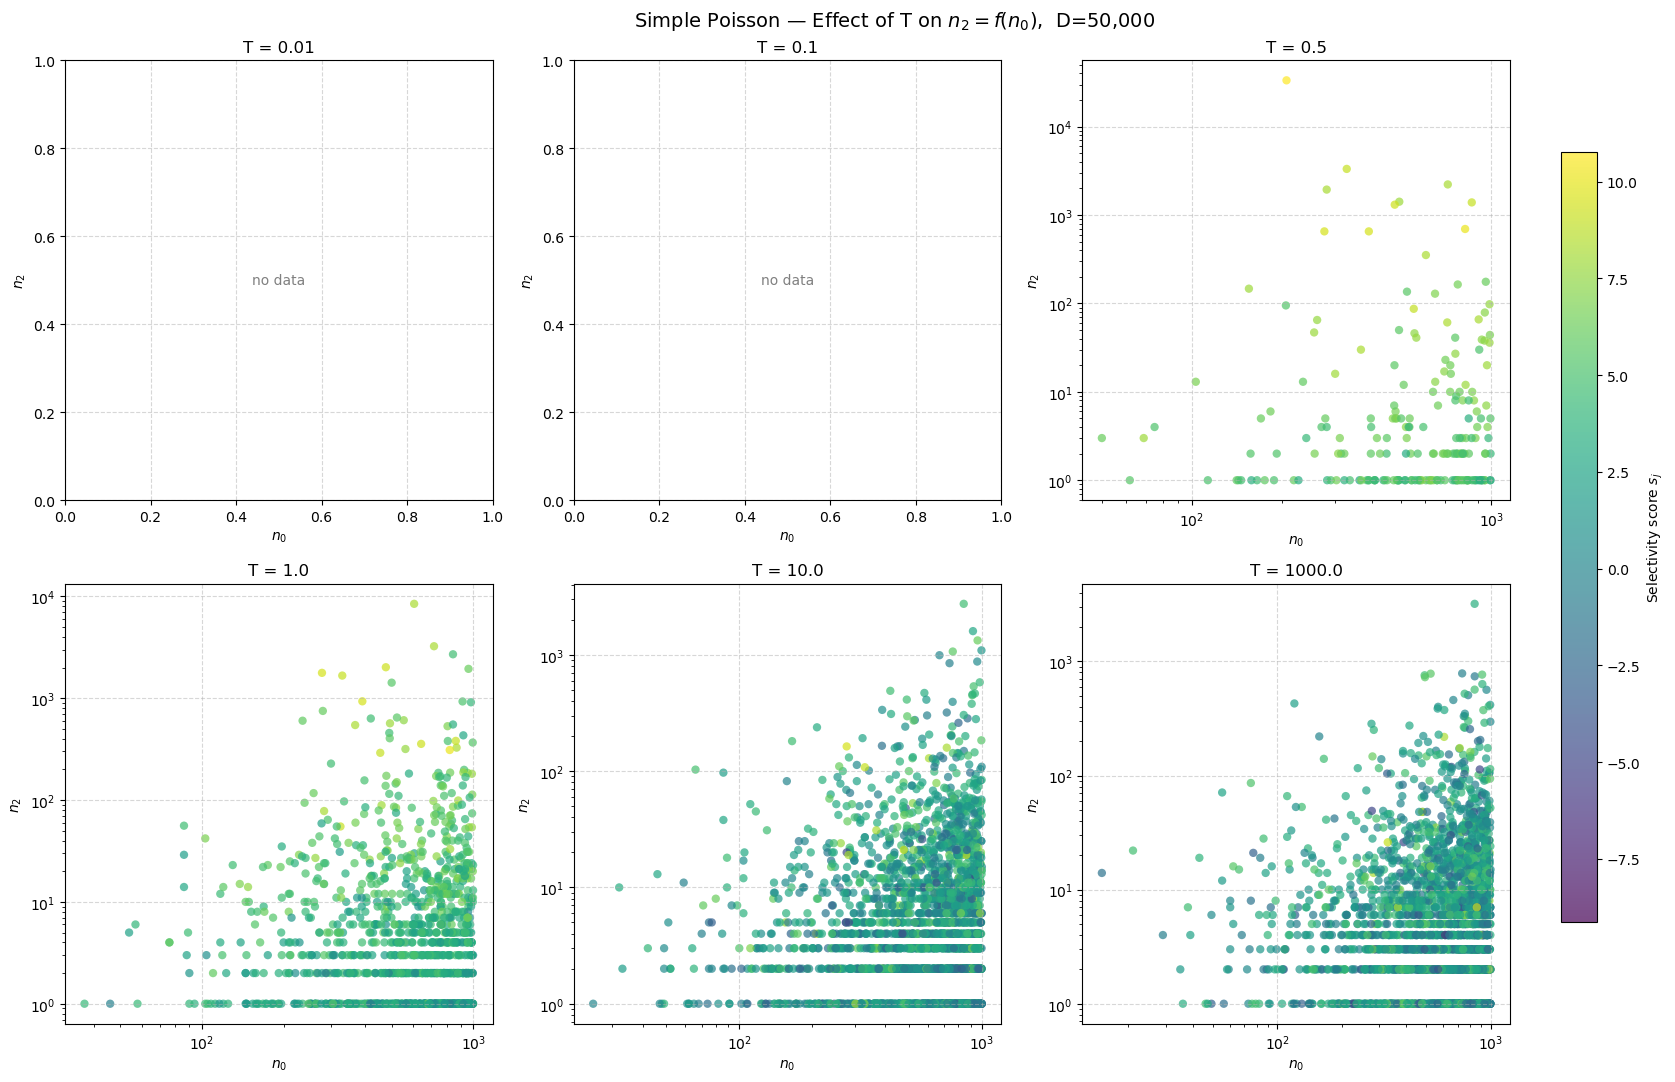

In [ ]:
T_values = [0.01, 0.1, 0.5, 1.0, 10.0, 1000.0]
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

sc = None
k_s = key_simple
for i, T_val in enumerate(T_values):
    k_s, sub_s = jax.random.split(k_s)
    l0, caps, lp, n2_t = protocol(
        n0, sequences, viability_weights, selectivity_weights, epsilon, epsilon, alpha, rho, T_val, T_viab, M, K_MM, D, N_pcr, N1,
        sub_s, use_full_ngs=False
    )
    mask = (n0 > 0) & (n2_t > 0)
    if mask.any():
        sc = axes[i].scatter(n0[mask], n2_t[mask], c=selectivity_scores[mask],
                             cmap='viridis', alpha=0.7, edgecolors='none',
                             vmin=float(selectivity_scores.min()), vmax=float(selectivity_scores.max()))
        axes[i].set_xscale('log'); axes[i].set_yscale('log')
    else:
        axes[i].text(0.5, 0.5, 'no data', transform=axes[i].transAxes,
                     ha='center', va='center', color='gray')
    axes[i].set_title(f'T = {T_val}')
    axes[i].set_xlabel(r'$n_0$'); axes[i].set_ylabel(r'$n_2$')
    axes[i].grid(True, linestyle='--', alpha=0.5)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
if sc is not None:
    fig.colorbar(sc, cax=cbar_ax, label='Selectivity score $s_j$')
plt.suptitle(f'Simple Poisson — Effect of T on $n_2 = f(n_0)$,  D={D:,}', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


/var/folders/xf/g2dzx3814xx2yfk3fln8r_zc0000gn/T/ipykernel_28141/2844707100.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


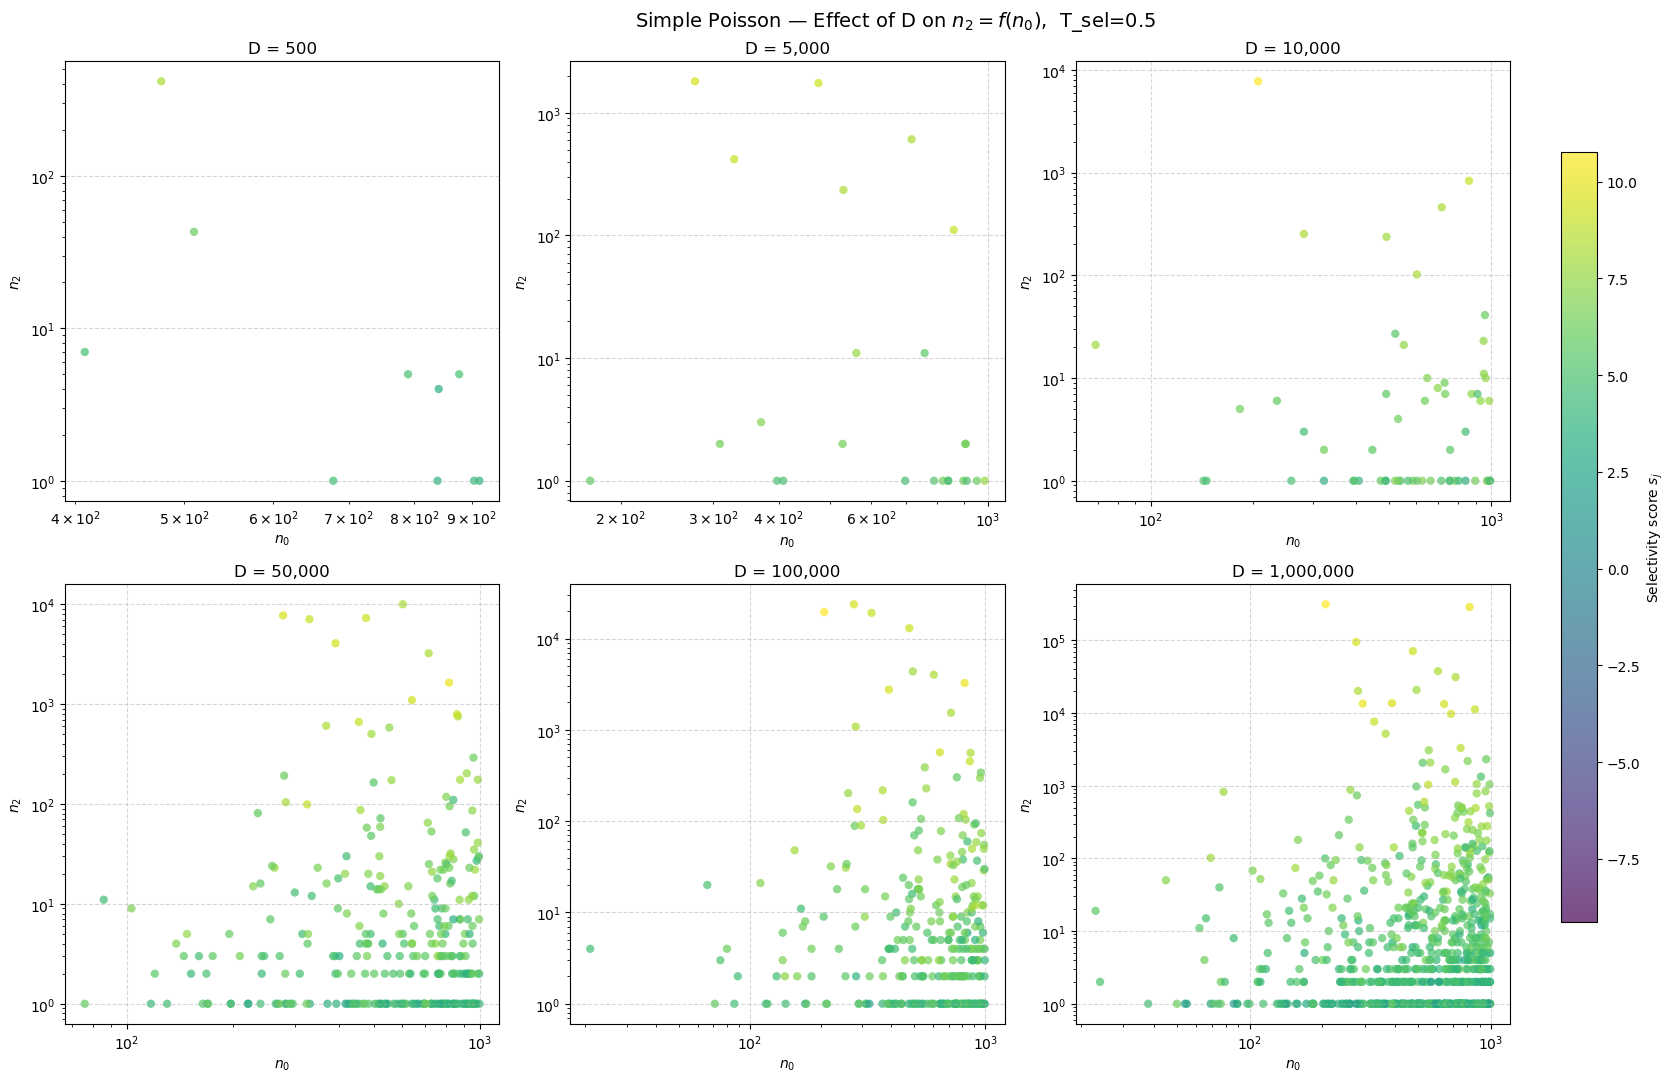

In [ ]:
D_values = [500, 5_000, 10_000, 50_000, 100_000, 1_000_000]
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

sc = None
k_s = key_simple
for i, D_val in enumerate(D_values):
    k_s, sub_s = jax.random.split(k_s)
    l0, caps, lp, n2_d = protocol(
        n0, sequences, viability_weights, selectivity_weights, epsilon, epsilon, alpha, rho, T_sel, T_viab, M, K_MM, D_val, N_pcr, D_val,
        sub_s, use_full_ngs=False
    )
    mask = (n0 > 0) & (n2_d > 0)
    if mask.any():
        sc = axes[i].scatter(n0[mask], n2_d[mask], c=selectivity_scores[mask],
                             cmap='viridis', alpha=0.7, edgecolors='none',
                             vmin=float(selectivity_scores.min()), vmax=float(selectivity_scores.max()))
        axes[i].set_xscale('log'); axes[i].set_yscale('log')
    else:
        axes[i].text(0.5, 0.5, 'no data', transform=axes[i].transAxes,
                     ha='center', va='center', color='gray')
    axes[i].set_title(f'D = {D_val:,}')
    axes[i].set_xlabel(r'$n_0$'); axes[i].set_ylabel(r'$n_2$')
    axes[i].grid(True, linestyle='--', alpha=0.5)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
if sc is not None:
    fig.colorbar(sc, cax=cbar_ax, label='Selectivity score $s_j$')
plt.suptitle(f'Simple Poisson — Effect of D on $n_2 = f(n_0)$,  T_sel={T_sel}', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


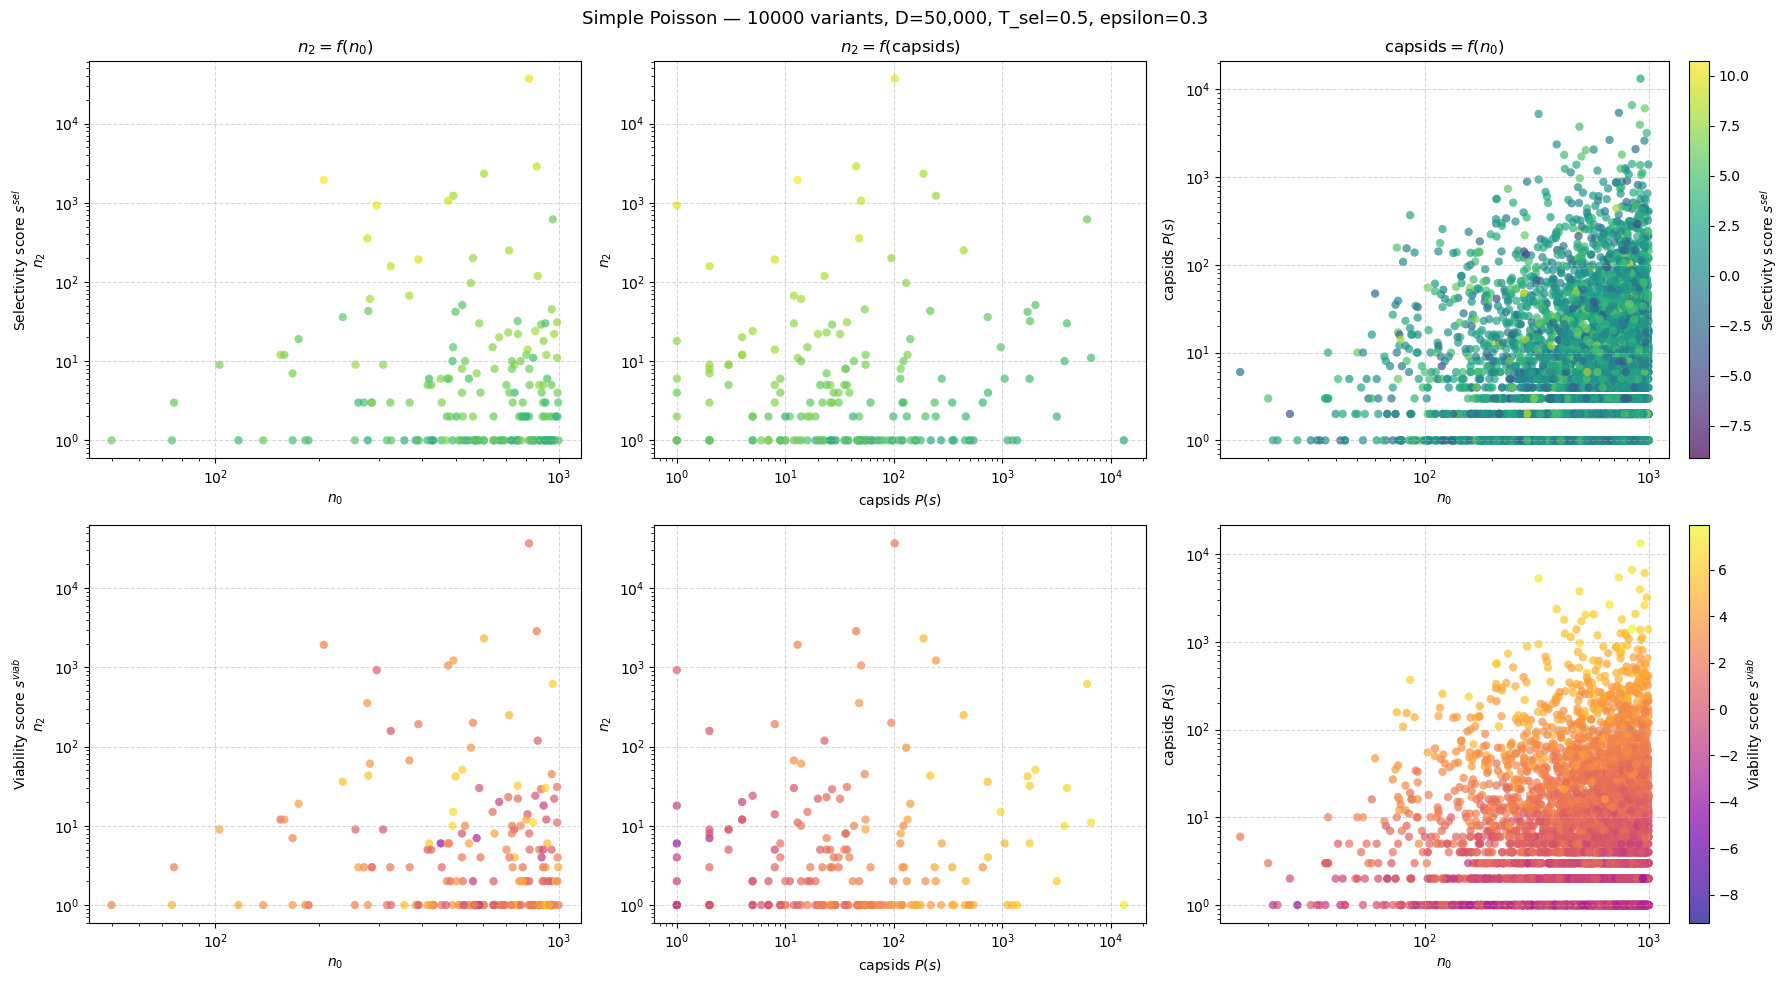

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sel_min,  sel_max  = float(selectivity_scores.min()), float(selectivity_scores.max())
viab_min, viab_max = float(viability_scores.min()),   float(viability_scores.max())

pairs = [
    (n0,      n2_s,    r'$n_0$',          r'$n_2$',          r'$n_2 = f(n_0)$'),
    (capsids_s,  n2_s,    r'capsids $P(s)$', r'$n_2$',          r'$n_2 = f(\mathrm{capsids})$'),
    (n0,      capsids_s,  r'$n_0$',          r'capsids $P(s)$', r'$\mathrm{capsids} = f(n_0)$'),
]

for row, (color_scores, vmin, vmax, cmap, row_label) in enumerate([
    (selectivity_scores, sel_min,  sel_max,  'viridis', 'Selectivity score $s^{sel}$'),
    (viability_scores,   viab_min, viab_max, 'plasma',  'Viability score $s^{viab}$'),
]):
    for col, (x, y, xlabel, ylabel, title) in enumerate(pairs):
        ax = axes[row, col]
        mask = (x > 0) & (y > 0)
        if mask.any():
            sc = ax.scatter(x[mask], y[mask], c=color_scores[mask],
                            cmap=cmap, alpha=0.7, edgecolors='none',
                            vmin=vmin, vmax=vmax)
            ax.set_xscale('log'); ax.set_yscale('log')
            if col == 2:
                plt.colorbar(sc, ax=ax, label=row_label, fraction=0.046, pad=0.04)
        else:
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                    ha='center', va='center', color='gray')
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.set_title(title if row == 0 else '')
        ax.grid(True, linestyle='--', alpha=0.5)
    axes[row, 0].set_ylabel(row_label + '\n' + axes[row, 0].get_ylabel())

plt.suptitle(f'Simple Poisson — {num_sequences} variants, D={D:,}, T_sel={T_sel}, epsilon={epsilon}', fontsize=13)
plt.tight_layout()
plt.show()


## 7b. Full NGS Pipeline

Sampling + PCR amplification (Michaelis–Menten) + sequencing (`Sequence_NGS_pipeline`).

/var/folders/xf/g2dzx3814xx2yfk3fln8r_zc0000gn/T/ipykernel_28141/2043767008.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


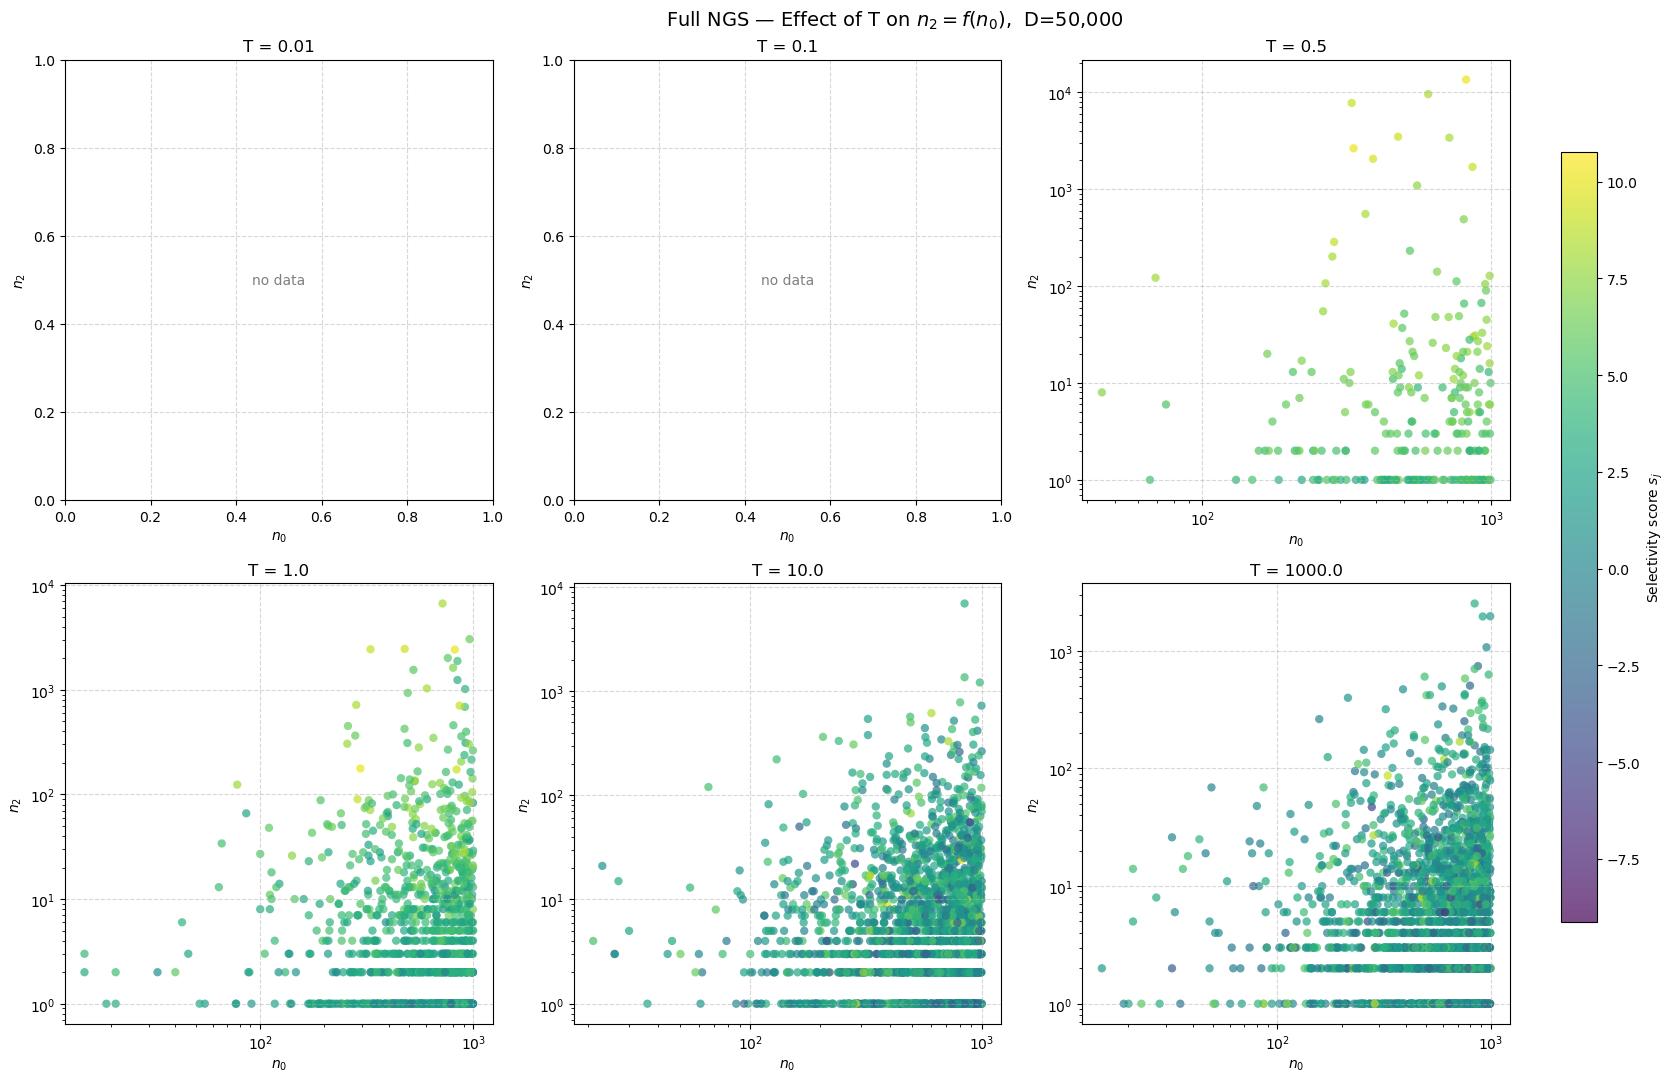

In [ ]:
T_values = [0.01, 0.1, 0.5, 1.0, 10.0, 1000.0]
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

sc = None
k_f = key_full
for i, T_val in enumerate(T_values):
    k_f, sub_f = jax.random.split(k_f)
    l0, caps, lp, n2_t = protocol(
        n0, sequences, viability_weights, selectivity_weights,
        epsilon, epsilon, alpha, rho, T_val, T_viab, M, K_MM, D, N_pcr, N1,
        sub_f, use_full_ngs=True
    )
    mask = (n0 > 0) & (n2_t > 0)
    if mask.any():
        sc = axes[i].scatter(n0[mask], n2_t[mask], c=selectivity_scores[mask],
                             cmap='viridis', alpha=0.7, edgecolors='none',
                             vmin=float(selectivity_scores.min()), vmax=float(selectivity_scores.max()))
        axes[i].set_xscale('log'); axes[i].set_yscale('log')
    else:
        axes[i].text(0.5, 0.5, 'no data', transform=axes[i].transAxes,
                     ha='center', va='center', color='gray')
    axes[i].set_title(f'T = {T_val}')
    axes[i].set_xlabel(r'$n_0$'); axes[i].set_ylabel(r'$n_2$')
    axes[i].grid(True, linestyle='--', alpha=0.5)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
if sc is not None:
    fig.colorbar(sc, cax=cbar_ax, label='Selectivity score $s_j$')
plt.suptitle(f'Full NGS — Effect of T on $n_2 = f(n_0)$,  D={D:,}', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


/var/folders/xf/g2dzx3814xx2yfk3fln8r_zc0000gn/T/ipykernel_28141/1963967808.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


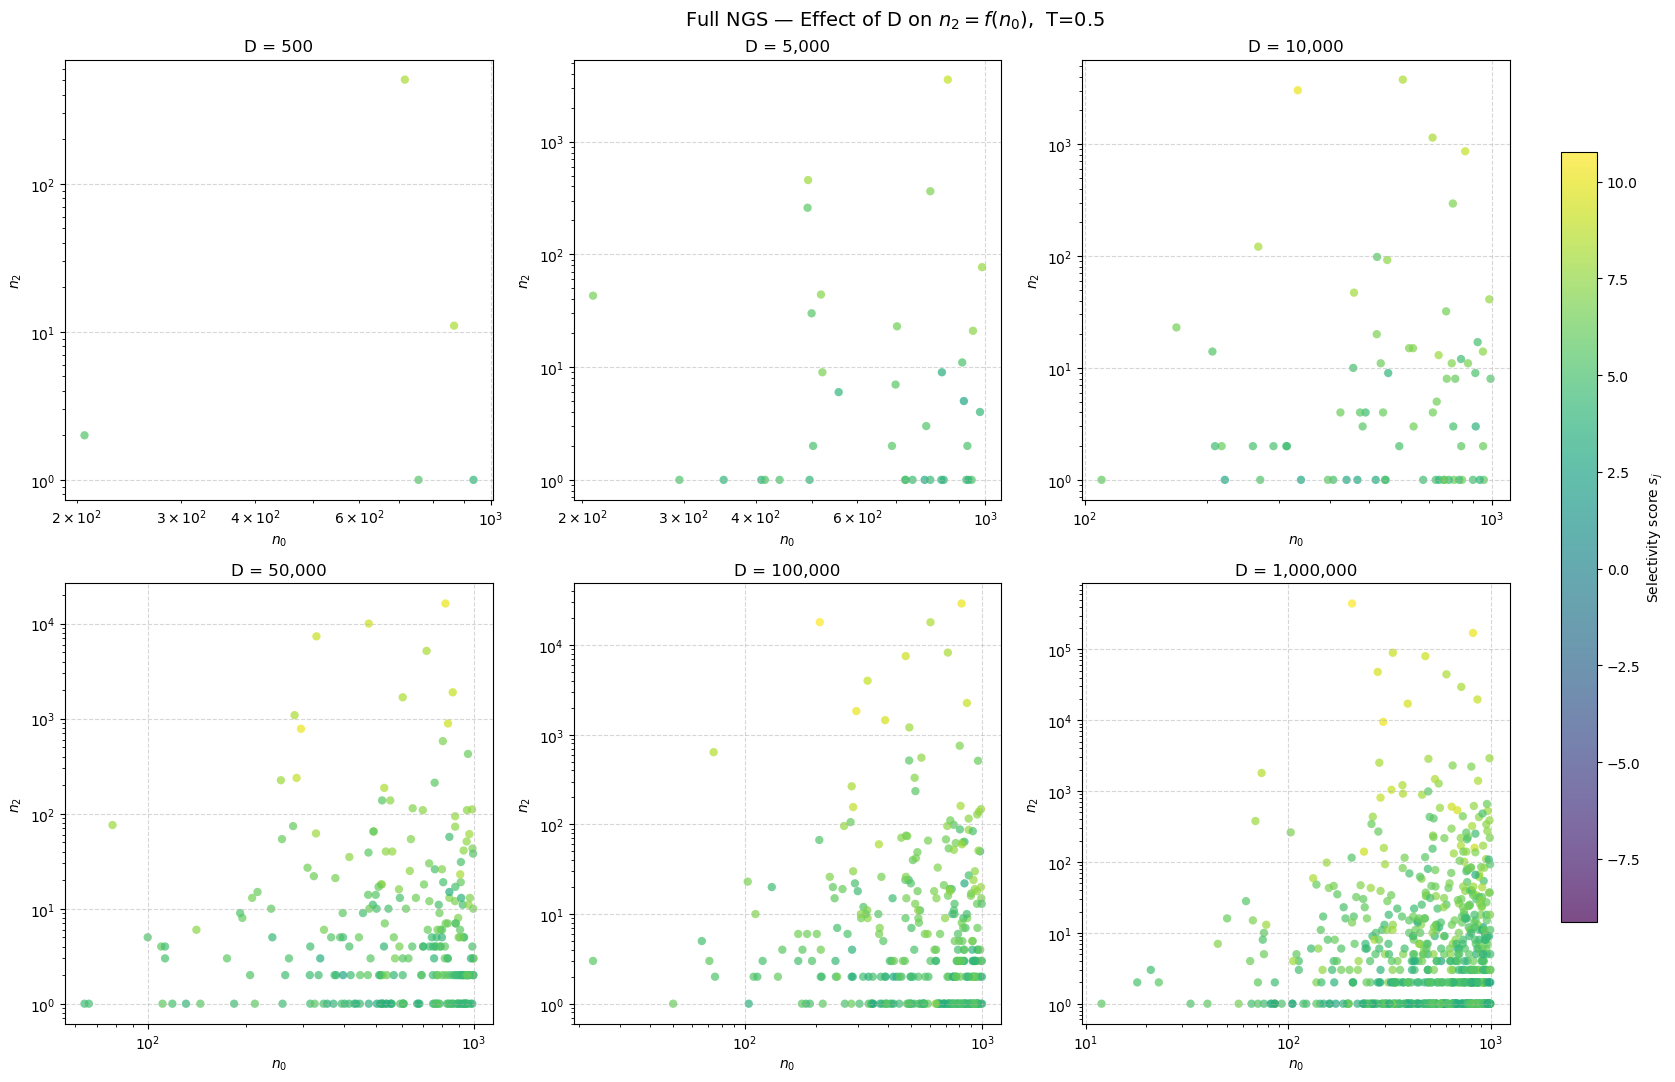

In [ ]:
D_values = [500, 5_000, 10_000, 50_000, 100_000, 1_000_000]
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

sc = None
k_f = key_full
for i, D_val in enumerate(D_values):
    k_f, sub_f = jax.random.split(k_f)
    l0, caps, lp, n2_d = protocol(
        n0, sequences, viability_weights, selectivity_weights,
        epsilon, epsilon, alpha, rho, T_sel, T_viab, M, K_MM, D_val, N_pcr, D_val,
        sub_f, use_full_ngs=True
    )
    mask = (n0 > 0) & (n2_d > 0)
    if mask.any():
        sc = axes[i].scatter(n0[mask], n2_d[mask], c=selectivity_scores[mask],
                             cmap='viridis', alpha=0.7, edgecolors='none',
                             vmin=float(selectivity_scores.min()), vmax=float(selectivity_scores.max()))
        axes[i].set_xscale('log'); axes[i].set_yscale('log')
    else:
        axes[i].text(0.5, 0.5, 'no data', transform=axes[i].transAxes,
                     ha='center', va='center', color='gray')
    axes[i].set_title(f'D = {D_val:,}')
    axes[i].set_xlabel(r'$n_0$'); axes[i].set_ylabel(r'$n_2$')
    axes[i].grid(True, linestyle='--', alpha=0.5)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
if sc is not None:
    fig.colorbar(sc, cax=cbar_ax, label='Selectivity score $s_j$')
plt.suptitle(f'Full NGS — Effect of D on $n_2 = f(n_0)$,  T={T_sel}', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


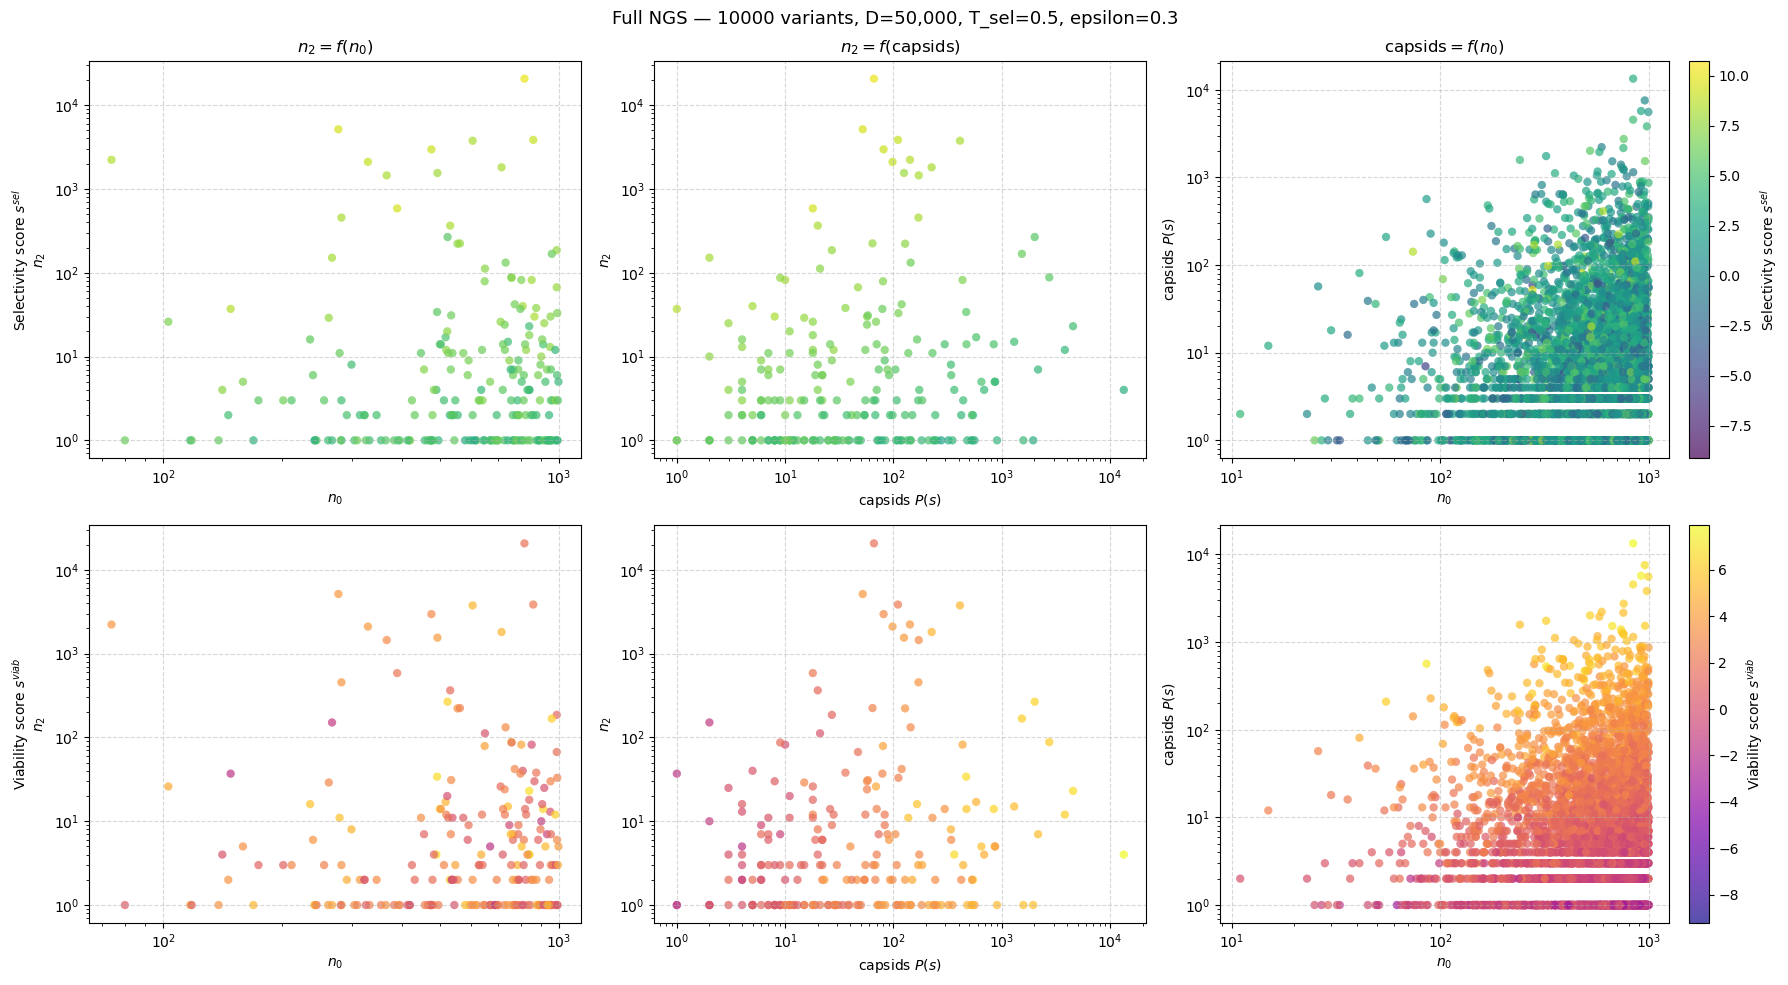

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sel_min,  sel_max  = float(selectivity_scores.min()), float(selectivity_scores.max())
viab_min, viab_max = float(viability_scores.min()),   float(viability_scores.max())

pairs = [
    (n0,        n2_f,      r'$n_0$',          r'$n_2$',          r'$n_2 = f(n_0)$'),
    (capsids_f, n2_f,      r'capsids $P(s)$', r'$n_2$',          r'$n_2 = f(\mathrm{capsids})$'),
    (n0,        capsids_f, r'$n_0$',          r'capsids $P(s)$', r'$\mathrm{capsids} = f(n_0)$'),
]

for row, (color_scores, vmin, vmax, cmap, row_label) in enumerate([
    (selectivity_scores, sel_min,  sel_max,  'viridis', 'Selectivity score $s^{sel}$'),
    (viability_scores,   viab_min, viab_max, 'plasma',  'Viability score $s^{viab}$'),
]):
    for col, (x, y, xlabel, ylabel, title) in enumerate(pairs):
        ax = axes[row, col]
        mask = (x > 0) & (y > 0)
        if mask.any():
            sc = ax.scatter(x[mask], y[mask], c=color_scores[mask],
                            cmap=cmap, alpha=0.7, edgecolors='none',
                            vmin=vmin, vmax=vmax)
            ax.set_xscale('log'); ax.set_yscale('log')
            if col == 2:
                plt.colorbar(sc, ax=ax, label=row_label, fraction=0.046, pad=0.04)
        else:
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                    ha='center', va='center', color='gray')
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.set_title(title if row == 0 else '')
        ax.grid(True, linestyle='--', alpha=0.5)
    axes[row, 0].set_ylabel(row_label + '\n' + axes[row, 0].get_ylabel())

plt.suptitle(f'Full NGS — {num_sequences} variants, D={D:,}, T_sel={T_sel}, epsilon={epsilon}', fontsize=13)
plt.tight_layout()
plt.show()


# PART 2 : Potts-model

### Here we consider pair interactions between amino-acids of each sequence 